<a href="https://colab.research.google.com/github/dytampn/TH_DeepLearning/blob/main/TH_DeepLearning_Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim


In [113]:
from google.colab import files
uploaded = files.upload()


Saving dulieuxettuyendaihoc.csv to dulieuxettuyendaihoc.csv


In [114]:
df = pd.read_csv('dulieuxettuyendaihoc.csv', sep=';')

In [115]:
print(df.head())
print(df.info())
print(df.shape)

   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   X6   D6   N6  GT  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.6  7.6  5.9   F   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  6.6  6.1  4.4   M   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  7.9  8.1  4.6   M   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  7.1  7.3  7.4   M   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.1  7.5  7.2   M   

   DT   KV   DH1   DH2   DH3  KT  
0 NaN  2NT  3.25  3.25  4.50  A1  
1 NaN    1  6.00  4.00  3.50   C  
2 NaN    1  5.00  6.75  4.00   C  
3 NaN    1  4.25  4.25  5.25  D1  
4 NaN  2NT  4.25  4.50  5.00   A  

[5 rows x 56 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null    float64
 2   L1      100 non-null    float64
 3 

In [116]:
print("\nDữ liệu thiếu:")
print(df.isnull().sum())


Dữ liệu thiếu:
STT     0
T1      0
L1      0
H1      0
S1      0
V1      0
X1      0
D1      0
N1      0
T2      0
L2      0
H2      0
S2      0
V2      0
X2      0
D2      0
N2      0
T3      0
L3      0
H3      0
S3      0
V3      0
X3      0
D3      0
N3      0
T4      0
L4      0
H4      0
S4      0
V4      0
X4      0
D4      0
N4      0
T5      0
L5      0
H5      0
S5      0
V5      0
X5      0
D5      0
N5      0
T6      0
L6      0
H6      0
S6      0
V6      0
X6      0
D6      0
N6      0
GT      0
DT     97
KV      0
DH1     0
DH2     0
DH3     0
KT      0
dtype: int64


In [117]:
# Cột DT có giá trị thiếu
df['DT'] = df['DT'].fillna('Unknown')

In [118]:
# Các cột object:
# GT, DT, KV, KT

df = pd.get_dummies(
    df,
    columns=['GT', 'DT', 'KV', 'KT']
)

In [119]:
X = df.drop(columns=['DH1'])
y = df['DH1']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [121]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

print("\nKích thước:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Kích thước:
Train: (60, 64)
Validation: (20, 64)
Test: (20, 64)


In [122]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [123]:
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_val = y_scaler.transform(
    y_val.values.reshape(-1,1)
)

y_test = y_scaler.transform(
    y_test.values.reshape(-1,1)
)

In [124]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [125]:
class RegressionModel(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.linear1 = nn.Linear(input_dim, 16)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(16, 1)

    def forward(self, x):

        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x

In [126]:
input_dim = X_train.shape[1]

model = RegressionModel(input_dim)

print("\nModel:")
print(model)



Model:
RegressionModel(
  (linear1): Linear(in_features=64, out_features=16, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=16, out_features=1, bias=True)
)


In [127]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-5
)

In [128]:
epochs = 200

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ================= TRAIN =================

    model.train()

    predictions = model(X_train_tensor)

    train_loss = criterion(
        predictions,
        y_train_tensor
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    # ================= VALIDATION =================

    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val_tensor)

        val_loss = criterion(
            val_predictions,
            y_val_tensor
        )

    # lưu loss
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    # print
    if (epoch + 1) % 10 == 0:

        print(
            f'Epoch {epoch+1}/{epochs} | '
            f'Train Loss: {train_loss.item():.4f} | '
            f'Val Loss: {val_loss.item():.4f}'
        )

Epoch 10/200 | Train Loss: 0.9820 | Val Loss: 2.1316
Epoch 20/200 | Train Loss: 0.9641 | Val Loss: 2.1251
Epoch 30/200 | Train Loss: 0.9470 | Val Loss: 2.1234
Epoch 40/200 | Train Loss: 0.9306 | Val Loss: 2.1239
Epoch 50/200 | Train Loss: 0.9145 | Val Loss: 2.1256
Epoch 60/200 | Train Loss: 0.8987 | Val Loss: 2.1273
Epoch 70/200 | Train Loss: 0.8831 | Val Loss: 2.1290
Epoch 80/200 | Train Loss: 0.8677 | Val Loss: 2.1305
Epoch 90/200 | Train Loss: 0.8525 | Val Loss: 2.1315
Epoch 100/200 | Train Loss: 0.8379 | Val Loss: 2.1307
Epoch 110/200 | Train Loss: 0.8231 | Val Loss: 2.1296
Epoch 120/200 | Train Loss: 0.8081 | Val Loss: 2.1291
Epoch 130/200 | Train Loss: 0.7933 | Val Loss: 2.1276
Epoch 140/200 | Train Loss: 0.7786 | Val Loss: 2.1275
Epoch 150/200 | Train Loss: 0.7640 | Val Loss: 2.1262
Epoch 160/200 | Train Loss: 0.7495 | Val Loss: 2.1251
Epoch 170/200 | Train Loss: 0.7349 | Val Loss: 2.1250
Epoch 180/200 | Train Loss: 0.7206 | Val Loss: 2.1244
Epoch 190/200 | Train Loss: 0.7062 | 

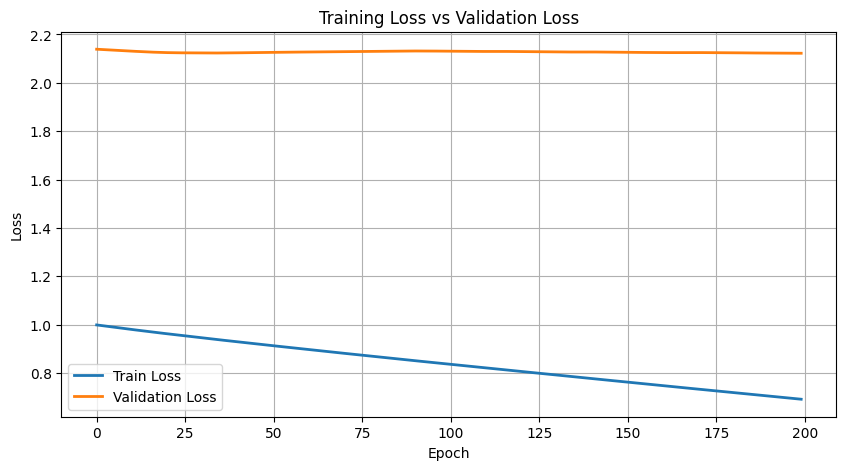

In [129]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, linewidth=2)
plt.plot(val_losses, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss vs Validation Loss")

plt.legend(["Train Loss", "Validation Loss"])

plt.grid(True)

plt.show()

In [130]:
model.eval()

with torch.no_grad():

    predictions = model(X_test_tensor)

In [131]:
y_pred = y_scaler.inverse_transform(
    predictions.numpy()
)

y_true = y_scaler.inverse_transform(
    y_test_tensor.numpy()
)

In [132]:
mse = mean_squared_error(
    y_true,
    y_pred
)

r2 = r2_score(
    y_true,
    y_pred
)

print("\nKẾT QUẢ:")

print("MSE:", mse)

print("R2 Score:", r2)


KẾT QUẢ:
MSE: 1.914419174194336
R2 Score: -0.1324782371520996


In [133]:
tolerance = 0.5

correct = np.abs(
    y_true - y_pred
) < tolerance

accuracy = np.mean(correct) * 100

print(f"Accuracy (+/-0.5 điểm): {accuracy:.2f}%")

Accuracy (+/-0.5 điểm): 20.00%


In [134]:
print("\n5 dự đoán đầu tiên:")

for i in range(5):

    print(
        f"Thật: {y_true[i][0]:.2f} "
        f"| Dự đoán: {y_pred[i][0]:.2f}"
    )


5 dự đoán đầu tiên:
Thật: 1.75 | Dự đoán: 4.13
Thật: 1.00 | Dự đoán: 3.51
Thật: 2.25 | Dự đoán: 3.61
Thật: 2.00 | Dự đoán: 3.62
Thật: 3.75 | Dự đoán: 3.52


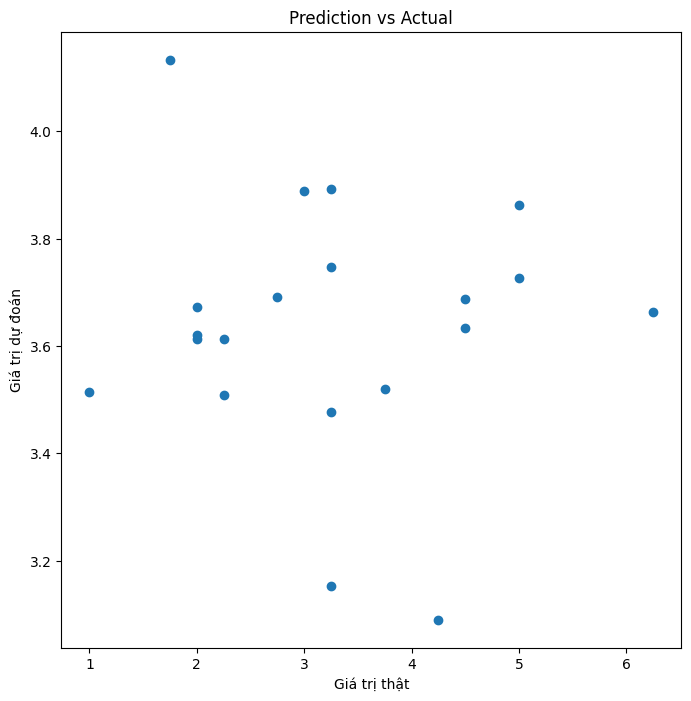

In [135]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_true,
    y_pred
)

plt.xlabel("Giá trị thật")
plt.ylabel("Giá trị dự đoán")

plt.title("Prediction vs Actual")

plt.show()